# Машинное обучение. ВМК МГУ

# Практическое задание 3: Основы sklearn на примере KNN. Нормализация признаков и Кросс-валидация

## Уровень: **Базовый (Base)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

- Многие из заданий можно выполнить несколькими способами.
Не существуют единственно верного, но попробуйте максимально
задействовать арсенал pandas и ориентируйтесь на простоту и понятность
вашего кода. Не забывайте, что можно гуглить и что-то искать на stackoverflow, например.

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: 10 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/sample_data/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.12MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

# Часть 0. Знакомство с библиотекой scikit-learn

Scikit-learn - это библиотека машинного обучения с
открытым исходным кодом, которая предоставляет различные инструменты для
предобработки данных и обучения моделей.

Подробную документацию с обширным количеством теоретических и практических примеров можно найти на сайте библиотеки

## Импорт библиотеки

Можно импортировать библиотеку целиком:

In [ ]:
import sklearn

Однако, так как библиотека очень обширная и содержит большое количество модулей , то импортируют либо модуль, либо классы/методы точечно и целенаправленно:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier # класс, с помощью которого мы в дальнейшем будем обучать kNN

**Подсказка** обычно по названию
модуля интуитивно понятно, какие методы и функции в нем содержатся. С
увеличением практики использования библиотеки вы сможете лучше и быстрее
навигироваться в ней. Например, модуль neighbors содержит различные
методы поиска ближайших соседей. Помните, что есть как версии для
классификации, так и для задач регрессии? Вот версию для классификации
мы выше как раз и импортировали. Однако если провалиться в описание модуля можно увидеть еще много разных классов и функций, которые так или иначе связаны с поиском соседей.

## Общее устройство моделей

Одним
из несравненных плюсов библиотеки является то, что она предоставляет
максимально общий и максимально понятный интерфейс взаимодействия с
различными алгоритмами машинного обучения.

Обычно, чтобы решить задачу машинного обучения, нам нужно (как минимум):

- Знать, какой моделью (алгоритмом) хотим воспользоваться
- Обучить ее на некоторое обучающей выборке
- Уметь узнавать предсказания модели на новой выборке

Вам не нужно запоминать для каждой конкретной модели, а как она
вообще обучается и как это написать: библиотека все делает за вас.

Каждая **модель машинного обучения** имеет два метода: fit - метод ответственный за обучения модели и predict - метод ответственный за предсказание целевой переменной.

- Как правило, метод fit принимает на вход два аргумента: X t r a i n X t r a i n - обучающая выборка, y t r a i n y t r a i n - значения целевых переменных на объектах обучающей выборки.
- Метод predict принимает на вход набор данных X t e s t X t e s t и выдает предсказанные значения целевых переменных y t e s t y t e s t на этом наборе данных.
- В моделях классификации бывает метод predict_proba , который принимает на вход набор данных и выдает вероятности принадлежности классам.

- Если нами решается задача классификации , то вектор целевых переменных y y содержит целые числа (или другое множество дискретных величин).
- При решении задачи регрессии вектор y y содержит вещественные числа.

**Выборка (данные)** X X представляется в виде матрицы размера (n_samples, n_features) , то есть каждому объекту соответствует отдельная строка, а каждому признаку - отдельный столбец.

**Целевая переменная** обычно представляется одномерным вектором размера (n_samples) - предсказаниями для каждого объекта, в случае предсказания вероятностей классов - матрицей размера (n_samples, n_classes) - значения вероктностей принадлежности объекта к тому или иному классу

Приведем пример стандартной работы с библиотекой scikit-learn

**Подсказка** Это совсем-совсем
базовый способ обучения моделей, на практике используют много
дополнительных приемов, постепенно которые мы будем с вами изучать

In [ ]:
#Создаем обучающую выборку
X_train = [[0], [1], [2], [3]] # матрица размера 4 x 1, 4 - объекта, 1 признак
y_train = [0, 0, 1, 1] # обучающий вектор целевых переменных

#Создаем тестовую выборку
X_test = [[1.1], [2.8]] # матрица размера 2x1, 2 - объекта, 1 признак

#Создаем объект класса 3-NN классификатора
neigh = KNeighborsClassifier(n_neighbors=3)

#Обучаем классифкатора на созданной ранее выборке
neigh.fit(X_train, y_train)

#Предсказываем метку класса нового объекта с помощью метода predict
y_test = neigh.predict(X_test)
print(y_test) # y_test - вектор размера 2 (в тестовой выборке 2 объекта)

[0 1]


## Общее устройство предобработки данных

На
практике почти никогда вы не встретите идеальных данных :) Вам всегда
понадобится на них посмотреть, проанализировать, где-то почистить,
где-то преобразовать и пр.

Упрощая, все работу с данными можно проделать с помощью 2 библиотек:

- pandas - с помощью этой библиотеки проанализировать
данные, посмотреть на то, что в них хранится, принять решение о удалении
мусора, замены каких-то значений и прочего. Данные техники вы совсем
немного затронули в предыдущем домашнем задании, но подробнее мы к ним
вернемся в следующем домашнем задании
- skelarn - технические способы обработки данных, особенности которых связаны непосредственно с моделью или способом обучения

**Пример** Данная библиотека поможет
решить вопрос: а как нам признаки с типом строка (например, название
видео) "запихнуть" в kNN? Он же только чиселки умеет понимать?

**Пример**
Или на следующий вопрос: с лекции немного припоминаю, что для более
хорошей работы метрических методов хорошо бы данные привести в один
масштаб. Как это можно быстро и безболезненно сделать?

Например, есть 2 признака:

- вероятность покупки p p - лежит на отрезке [0, 1]
- стоимость покупки s s - лежит на отрезке [0, 100000500000]

Хотелось бы чтобы оба признака были на отрезке [0, 1], потому что
покупка, кажется, может вносить гораздо больший вклад по расстоянию в
обучении модели..

В sklearn способы обработки данных также предоставляются через различные классы, которые имеют одинаковый интерфейс:

Каждый модуль предобработки данных имеет два метода: fit и transform .

- Как правило, метод fit принимает на вход обучающую выборку X t r a i n X t r a i n и считает по ней необходимые для заданного типа преобразования статистики.
- Метод transform преобразует входные данные, используя статистики, посчитанные при вызове метода fit и возвращает преобразованные данные.

**Пояснение:** Когда не хватает pandas или skelarn , можно обратиться к другим библиотекам, например, numpy
:) Sklearn обычно одинаково хорошо работает с данными, представленным
как и pd.DataFrame, так и numpy-array или обычными вложенными
питоновскими списками

In [ ]:
import numpy as np
X_train = np.array([[0, 0], [0.5, 100], [1, 1000005000]]) # numpy используем для удобства отображения
# выборка из 3 примеров, 1й признак - вероятность покупки p
# 2й признак - стоимость покупки s

print(X_train)

[[0.000000e+00 0.000000e+00]
 [5.000000e-01 1.000000e+02]
 [1.000000e+00 1.000005e+09]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler # штука, которая приводит все значения признаков к отрезку [0, 1]
# В части 1 подробнее разберем

scaler = MinMaxScaler() # создаем экземпляр класса

scaler.fit(X_train) # "обучаем" преобразователь, на самом деле под капотом считаются статистики
# X_train тут не меняется!

MinMaxScaler()


In [ ]:
# Теперь метод для каждого признака посчитал его минимальные и максимальные значения
# Но это под капотом, сюда можно вообще не лезть
scaler.data_min_, scaler.data_max_

(array([0., 0.]), array([1.000000e+00, 1.000005e+09]))


In [ ]:
X_new = scaler.transform(X_train)
X_new
# Значения в 1й признаке не поменялись, так как они уже удовлетворяли условию
# А во втором - стали на отрезке [0, 1]

array([[0.00000e+00, 0.00000e+00],
       [5.00000e-01, 9.99995e-08],
       [1.00000e+00, 1.00000e+00]])


# Часть 1. Нормализация признакового пространства

В задачах машинного обучения важную роль играет нормализация данных.
Ее мы затронули как раз выше. Для числовых признаков, как правило,
используют два типа нормализации:

- Нормализация к распределению с нулевым матожиданием и единичной дисперсией, x : = x − E ( x ) σ ( x ) x := x − E ( x ) σ ( x ) , где матожидание E ( x ) E ( x ) и стандартное отклонение σ ( x ) σ ( x ) считаются **по каждому признаку (столбцу) отдельно**
- Нормализация в отрезок [0, 1], x : = x − min ( x ) max ( x ) − min ( x ) x := x − min ( x ) max ( x ) − min ( x ) , где минимум и максимум берется **по каждому признаку (столбцу) отдельно** (как в примере выше)

**Пример**

Ниже приведены: таблица до нормализации признаков, таблица после
нормализации к нулевому матожиданию и единичной дисперсии, таблица после
нормализации в отрезок [0, 1]

**До нормализации**

Признак 1
Признак 2
1
2
2
-1
3
0

**Нормализация к нулевому матожиданию и единичной дисперсии**

Признак 1
Признак 2
-1.225
1.336
0
-1.069
1.225
-0.267

**Нормализация в отрезок [0, 1]**

Признак 1
Признак 2
0
1
0.5
0
1
0.333

### **Задание 1.1 (юнит-тесты, 4 баллa)**

В модуле scalers.py реализуйте два вида нормализации признакового пространства. StandardScaler - нормализация к распределению с нулевым матожиданием и единичной дисперсией, MinMaxScaler - нормализация в отрезок [0, 1].

Нормализаторы имеют два метода - метод fit и метод transform , что максимально повторяет концепцию sklearn . Метод fit получает на вход обучающую
выборку и считает по ней все необходимые для заданного преобразования
статистики, которые сохраняет во внутренние поля класса. Метод transform преобразует данные, используя статистистики, посчитанные при вызове метода fit .

Примеры запусков функций можно увидеть в открытых тестах.

**Внимание!** В текущую директорию
необходимо загрузить файл scalers.py с реализованными классами. В
Google Colab это можно сделать, нажав на значок "папки" слева, дальше на
"загрузить" (значок листа со стрелкой вверх). Загружать нужно в папку
"sample_data" (она у вас откроется по умолчанию)

**Внимание!** Перед тем, как выполнять
задание дальше, убедитесь, что ваша реализация проходит тесты с системе
проверке заданий, и вы загрузили сюда вашу реализацию

Теперь посмотрим работу "скейлеров" на примере данных:

In [ ]:
%cd /content/sample_data
!ls
from scalers import StandardScaler, MinMaxScaler

/content/sample_data
anscombe.json		      mnist_test.csv	     requirements_2024_25_for_colab_small.txt
california_housing_test.csv   mnist_train_small.csv  scalers.py
california_housing_train.csv  __pycache__
data.pkl		      README.md


In [ ]:
import numpy as np
import seaborn as sns
import pickle

from matplotlib import pyplot as plt


plt.rcParams["figure.figsize"] = (5,5)

Загрузим файл с данными data.pkl:

In [ ]:
!gdown 1acbP4PNmu11rkBzozvIc3bowWaQL7iFe

Downloading...
From: https://drive.google.com/uc?id=1acbP4PNmu11rkBzozvIc3bowWaQL7iFe
To: /content/sample_data/data.pkl
100% 5.03k/5.03k [00:00<00:00, 16.7MB/s]


Загрузим данные в память. В переменной X X будут храниться признаковые описания объектов, в переменной y − y − метки классов

In [ ]:
with open('data.pkl', 'rb') as file:
    X, y = pickle.load(file)

In [ ]:
def plot_data_points(X, labels, xlim, ylim):
    g = sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels)
    g.set(xlim=xlim, ylim=ylim)
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.grid()

Визуализируем наши данные

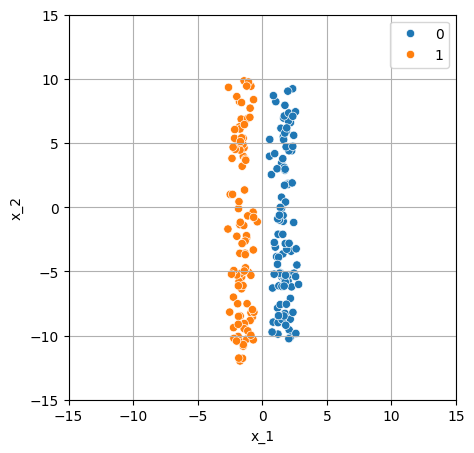

In [ ]:
plot_data_points(X, y, xlim=(-15, 15), ylim=(-15, 15))

Как видно, наши данные идеально разделяются прямой x = 0 x = 0

Функция p l o t _ k n n _ b o u n d p l o t _ k n n _ b o u n d принимает на вход объекты X X , метки классов y y , метод нормализации признаков s c a l e r s c a l e r , число соседей n _ n e i g h b o r s n _ n e i g h b o r s и границы рисунка x l i m x l i m , y l i m y l i m . Функция обучает K N N K N N классификатор с числом соседей n _ n e i g h b o r s n _ n e i g h b o r s и визуализирует разделяющую поверхность для классов, полученную с помощью обученного K N N K N N классификатора.

- Если вы не можете различить выбранные нами цвета , то измените список цветов в переменных cmap_light и cmap_bold. Актуальный список возможных цветов находится здесь

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

def plot_knn_bound(X, y, scaler=None, n_neighbors=10, xlim=(-15, 15), ylim=(-20, 20)):
    # step size in the mesh
    h = 0.05

    # Create color maps
    cmap_light = ListedColormap(['plum', 'blue', 'plum', 'green'][:np.unique(y).shape[0]])
    cmap_bold = ['plum', 'blue', 'plum', 'darkgreen'][:np.unique(y).shape[0]]

    x_min, x_max = xlim
    y_min, y_max = ylim
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    X_scaled = X # if scaler is None
    if scaler is not None:
        grid = scaler.transform(grid)
        X_scaled = scaler.transform(X)

    # we create an instance of Neighbours Classifier and fit the data.
    clf = neighbors.KNeighborsClassifier(n_neighbors, algorithm='brute')
    clf.fit(X_scaled, y)

    Z = clf.predict(grid)

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=cmap_bold, alpha=1.0, edgecolor="black")
    plt.xlabel('x_1')
    plt.ylabel('x_2')
    plt.title('Разделющие поверхности алгоритма {}-NN'.format(n_neighbors))
    plt.grid()
    plt.show()

Нарисуем разделющие поверхности 1 1 - N N N N и 10 10 - N N N N

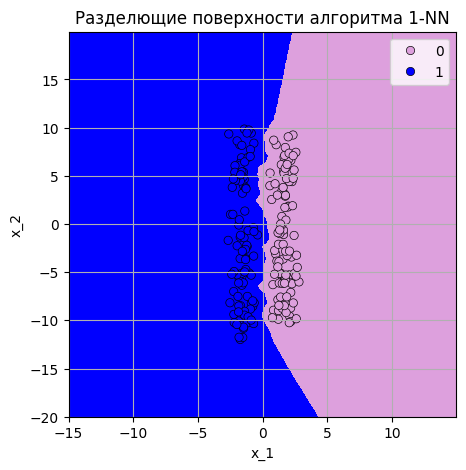

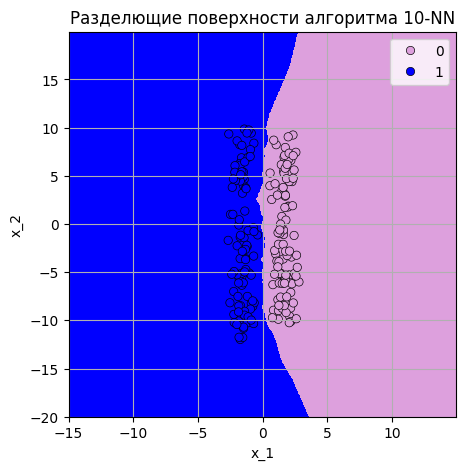

In [ ]:
plot_knn_bound(X, y, n_neighbors=1)
plot_knn_bound(X, y, n_neighbors=10)

### **Задание 1.2 (кросс-проверка, 2 балла)**

Чем отличаются поверхности, полученные при числе соседей 1 и 10? Объясните, чем вызваны данные отличия

**Когда мы выбрали значение 1, модель
переобучилась, и это привело к тому, что она стала чувствительна к
шумам, поэтому в случае с 10 соседями граница между плоскостями более
сглаженная**

### **Задание 1.3 (кросс-проверка, 1 балл)**

Данную проблему может решить нормализация признакового пространства.

Начертите разделяющие поверхности для K N N K N N , обученного на нормализованных признаках с помощью реализованных вами нормализаторов. Используйте функцию p l o t _ k n n _ b o u n d p l o t _ k n n _ b o u n d . Менять функцию p l o t _ k n n _ b o u n d p l o t _ k n n _ b o u n d нельзя.

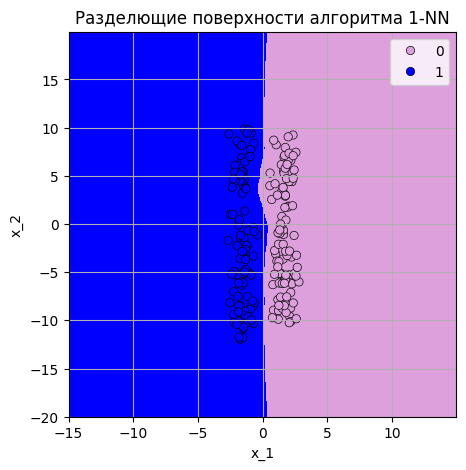

In [ ]:
scalerMM = MinMaxScaler()
scalerMM.fit(X)
plot_knn_bound(X, y, scaler = scalerMM, n_neighbors=1)

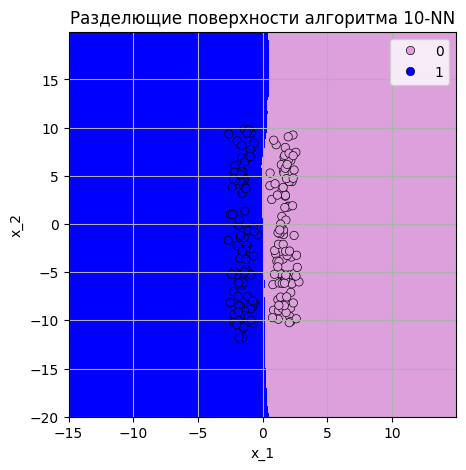

In [ ]:
scalerMM = MinMaxScaler()
scalerMM.fit(X)
plot_knn_bound(X, y, scaler = scalerMM, n_neighbors=10)

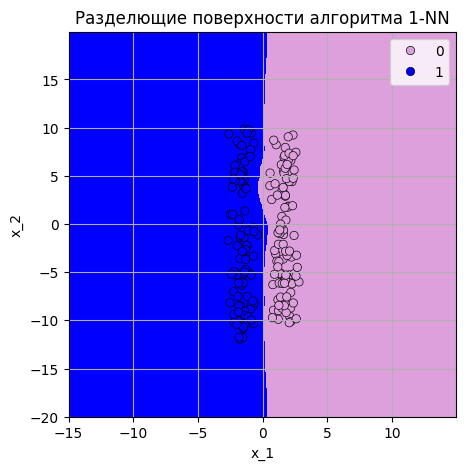

In [ ]:
scalerSS = StandardScaler()
scalerSS.fit(X)
plot_knn_bound(X, y, scaler = scalerSS, n_neighbors=1)

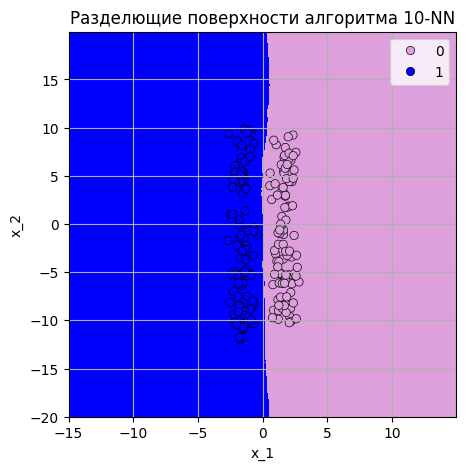

In [ ]:
scalerSS = StandardScaler()
scalerSS.fit(X)
plot_knn_bound(X, y, scaler = scalerSS, n_neighbors=10)

# Часть 2. Кросс-валидация на задаче регрессии

Часто модели в машинном обучении имеют вид не просто какой-то функции, а какой-то функции с некоторыми, так называемыми **гиперпараметрами**
- это такие переменные величины, которые могут существенно повлиять на
качество и вид модели, но напрямую обучить их нельзя (то есть в методе
fit они вообще не обучаются). Одним из примеров таких гиперпараметров
является:

n_neighbors - кол-во соседей в методах kNN. Если
вернуться в начало ноутбука, то можно увидеть, что имено это значение мы
явно задавали, когда создавали модель с помощью класса KNeighborsClassifier.

В этот момент возникает **закономерный вопрос:** а как нам найти то значение гиперпараметров, при которых наша модель будет показывать более высокие результаты решения задачи?

Продолжаем проваливаться в "кроличью нору" дальше. Для того, чтобы ответить на предыдущий вопрос, нужно сначала понять **следующее:**
а как оценивать-то собственно качество моделей? Пусть даже мы
зафиксировали какой-то гиперпараметр, как нам оценивать, насколько наша
модель хороша?

Чтобы уметь оценивать качество моделей ("насколько вообще хорошо мы
решили задачу") хочется иметь некий "стандарт качества" - данные,
которые вообще не участвовали в обучении ("модель их не видела") и
верные ответы на этих данных (которые модель также не видела)

При решении прикладных задач, как правило, доступна лишь обучающая
выборка, а "стандарт качества" зачастую отсутствует. Решить данную
проблему нам поможет техника, называемая **кросс-валиация** .
Данная техника позволяет создавать "стандарты качества" (тестовые
наборы, выборки) используя только обучающую выборку, но не позволяя
модели "подглядывать" в создаваемые тестовые наборы.

**Алгоритм применения кросс-валидации**

Пусть зафиксирован некоторый набор значений гиперпараметров модели. В K N N K N N под гиперпараметрами могут пониматься число соседей n_neighbors, метрика близости ρ ρ , стратегия выбора весов w i w i .

- При кросс-валидации **обучающая** выборка делится на n n равных частей (folds, фолды).
- Затем обучаются n n моделей с заданными гиперпараметрами (у всех моделей гиперпараметры одинаковые и фиксированы) - i i -ая модель обучается на всей обучающей выборке, **кроме объектов, которые попали в i i -ый фолд (out-of-fold).**
- i i -й фолд объявляется "стандартом качества" (тестовым). Затем измеряется качество i i -ой модели на i i -ом фолде. Так как он не участвовал в обучении этой модели, то полученная оценка качества модели будет являться корректной.
- Финальным значением метрики качества для модели с заданными гиперпараметрами является **среднее полученных нами значений** на n n фолдах.

**Идея:** Подумайте, как в описанную
выше схему корректно добавить обучение скейлеров. Корректно ли будет
масштабировать сначала все данные и потом делать кросс-валидацию или
все-таки нужно как-то действовать хитрее?

Собственно, теперь мы можем выбрать наилучшие гиперпараметры по следующему алгоритму:

- Фиксируем, какие значения гиперпараметров хотим перебрать
- Для каждого набора значений проводим кросс-валидацию
- Для каждого набора значений сохраняем качество на кросс-валидации
- Выбираем тот набор значений гиперпараметров, где качество оказыается наилучшим!

Принцип работы кросс-валидации схематично изображен на рисунке.

Небольшое видео объяснение о том, как работает кросс-валидация, можно посмотреть по ссылке

Теперь применем все полученные знания на практике на примере тренировочного датасета!

Далее будем решать задачу предсказания цены дома в Калифорнии с помощью K N N K N N -
регрессии. Цена дома - вещественное число, поэтому наша задача - задача
регрессии. В качестве метрики качества будем использовать R 2 − R 2 − score.

R 2 ( y _ t r u e , y _ p r e d i c t ) = 1 − ∑ n i = 1 ( y _ t r u e i − y _ p r e d i c t i ) 2 ∑ n i = 1 ( y _ t r u e i − E ( y _ t r u e i ) ) 2 R 2 ( y _ t r u e , y _ p r e d i c t ) = 1 − ∑ i = 1 n ( y _ t r u e i − y _ p r e d i c t i ) 2 ∑ i = 1 n ( y _ t r u e i − E ( y _ t r u e i ) ) 2

**Примечание** вы же помните, что
предсказания и верные ответы можно оценивать по-разному и это называется
метриками качества? Если данная теория подзабылась, то освежите,
пожалуйста, знания лекционным материалом

In [ ]:
from sklearn.datasets import fetch_california_housing # Да, из sklearn даже можно импортировать данные
from sklearn.model_selection import train_test_split # Вспомогательная функцию которая разобьет нам датасет на 2 части

In [ ]:
X, y = fetch_california_housing(return_X_y=True)

Мы разобьем выборку на 2 части: обучающую (75%) и тестовую (25%) с помощью функции t r a i n _ t e s t _ s p l i t t r a i n _ t e s t _ s p l i t . По умолчанию данная функцию перемешивает данные, что часто оказывается полезно в задачах подобного рода.

Зачем мы разбиваем? Мы пытаемся "эмулировать" жизеннную ситуацию.
ML-разработчику приносят данные, говорят "обучи как можно лучше", потом
мы протестируем твою модель на новых данных. Вот та тестовая выборка,
которую мы выделили (25%) - это те данные, **в которые ни в коем случае во время обучения подглядывать нельзя** , нас потом на них будут проверять!

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Pipeline и перебор гиперпараметров

Кросс-валидация в skelarn , как нетрудно догадаться, уже реализована, остается научиться ее запускать :)

Но перед этим изучим еще парочку джедайских техник работы с sklearn , которые облегчат жизнь при написании моделей

In [ ]:
from sklearn.neighbors import KNeighborsRegressor # kNN - регрессия
from sklearn.pipeline import Pipeline # разберем ниже
from sklearn.model_selection import GridSearchCV # класс, выполняющий кросс-валидацию
from sklearn.preprocessing import MinMaxScaler, StandardScaler # будем здесь использовать уже реализованные скейлеры

Что нам собственно нужно при решении задачи с учетом кросс-валидации?

- Понять, предобрабатываем ли мы как-то данные или нет
- Зафиксировать модель
- Зафиксировать метрику качества
- Понять, какие гиперпараметры мы хотим перебрать
- Собственно выбрать лучший набор с помощью кросс-валидации
- И оценить, а что на тестовой выборке-то получилось!

Шаг 1 и шаг 2 - объединяются логически - часто бывает так, что нам
сначала нужно применить логику предобработки данных, а затем уже
применить и обучить модель.

Логическая цепочка в таком случае будет выглдять так:

```
X -> предобрабатываем X -> X уходит в fit некоторой модели
```

sklearn Предоставляет удобное решение для составление
таких цепочек-шагов обработки результатов, полученных на предыдущем
шаге. Инструмент назвается Pipeline (пайплайны):

In [ ]:
pipeline = Pipeline([
    ('normalizer', MinMaxScaler()),
    ('classifier', KNeighborsRegressor())
])

В данном примере вы говорим, что хотим, чтобы сначала данные
отскелились, а потом, что получилось, подалось бы модели. Причем шаги
этой цепочки обозначены строковыми и понятными обозначениям, которые нам
скоро понадобятся

Pipeline наследует абсолютно то же интерфейс, что и остальные модули обучения в sklearn - имеет методы fit и predict ! То есть получили некоторый "сборный конструктор" из различных частей.

In [ ]:
pipeline.fit(X_train, y_train)
pipeline.predict(X_test)

array([0.5482  , 0.7506  , 4.628604, ..., 1.328   , 2.4206  , 4.089404])


Далее встает вопрос: а как этот процесс обучения можно варьировать? В самом KNeighborsRegressor много гиперпараметров (число соседей, метрика расстояния и пр.), которые задаются при создании класса, а мы в Pipeline
создали дефолтный экземпляр класса.. И вообще, можно же еще и
перебирать, хотим ли мы использовать скейлер или нет, вдруг будет лучше
без него? (а такое тоже бывает!)

И здесь sklearn нас снова выручает и дает возможность варьировать создание моделей, которые мы используем в Pipeline :

In [ ]:
parameters = {
    'classifier__n_neighbors': [1, 5, 10],
    'classifier__metric': ['euclidean', 'cosine'],
    'classifier__weights': ['uniform', 'distance'],
    'normalizer': ['passthrough', MinMaxScaler(), StandardScaler()]
}

Мы можем задать такой словарик типа str -> list , который будет описывать все наши изменения, которые должны будут примениться в Pipeline (применяться они будут через класс кросс-валидации)

Если в качестве ключа написать ровно то название, которым мы обозначили шаг в Pipeline , то потом появляется возможность программно сопоставить эти два шага и заменить значения в Pipeline :

```
'normalizer': ['passthrough', MinMaxScaler(), StandardScaler()]
```

В данном случае у нас в Pipeline значения в названии шага normalizer будут меняться в соответствии с предложенными вариантам в списке

**Пояснение:** passthrough - ключевое слово, которые говорит sklearn "пропусти этот шаг"

А здесь уже логика чуть посложнее: у класса KNeighborsRegressor ,
который лежит в шаге classifier, при создании можно указать различный
набор гиперпараметров, например, тот же n_negihbors. Обращаясь через
двойное нижнее подчеркивание появляется возможность на лету изменять
значения этих гиперпараметров в классе:

```
'classifier__n_neighbors': [1, 5, 10]
```

Здесь мы говорим "посмотри, что за модель лежит на шаге classifier, и
замени у нее гиперпараметр n_neighbors в соответствии с сеткой
перебора"

### **Задание 2.1 (кросс, 2 балла)**

Запустите кросс-валидацию на 3 фолдах с помощью класса GridSearchCV и метода f i t f i t этого модуля. В качестве метрики используйте R 2 R 2 -score (строкое представление в sklearn "r2"). Параметры для перебора описаны ниже

In [ ]:
# задаем нужный пайплайн
pipeline = Pipeline([
    ('normalizer', 'passthrough'),
    ('classifier', KNeighborsRegressor())
])

# и сетку перебора параметров
parameters = {
    'classifier__n_neighbors': [1, 5, 10],
    'classifier__metric': ['euclidean', 'cosine'],
    'classifier__weights': ['uniform', 'distance'],
    'normalizer': ['passthrough', MinMaxScaler(), StandardScaler()]
}

grid_search = GridSearchCV(pipeline, parameters, cv=3, n_jobs=-1, verbose=10, scoring='r2')
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('normalizer', 'passthrough'),
                                       ('classifier', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'cosine'],
                         'classifier__n_neighbors': [1, 5, 10],
                         'classifier__weights': ['uniform', 'distance'],
                         'normalizer': ['passthrough', MinMaxScaler(),
                                        StandardScaler()]},
             scoring='r2', verbose=10)


Посмотрим на результаты кросс-валидации. Посмотреть результаты можно удобно через аттрибут cv_results_ :

In [ ]:
for elem in zip (grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
  print(elem)

({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform', 'normalizer': 'passthrough'}, -0.2698362539419594)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform', 'normalizer': MinMaxScaler()}, 0.5329368736058075)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform', 'normalizer': StandardScaler()}, 0.5139255367340351)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'distance', 'normalizer': 'passthrough'}, -0.2698362539419594)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'distance', 'normalizer': MinMaxScaler()}, 0.5329368736058075)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'distance', 'normalizer': StandardScaler()}, 0.5139255367340351)
({'classifier__metric': 'euclidean', 'classifier__n_neighbors': 5, 'classifier__w

### **Задание 2.2 (кросс, 1 балл)**

Какой наибольший r 2 _ s c o r e r 2 _ s c o r e удалось достичь на кросс-валидации? Какие закономерности вы видите?

- Обучите модель с наилучшими параметрами на всей обучающей выборке
- измерьте r 2 _ s c o r e r 2 _ s c o r e на тестовой выборке.

In [ ]:
print ("Лучшие параметры: ", grid_search.best_params_)
print ("Лучший R2 score на кросс-валидации: ", grid_search.best_score_)
best_model = grid_search.best_estimator_
best_model. fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print("R2 score на тестовой выборке: ", r2_score(y_test, y_pred))

Лучшие параметры:  {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 10, 'classifier__weights': 'distance', 'normalizer': MinMaxScaler()}
Лучший R2 score на кросс-валидации:  0.7035316821435433
R2 score на тестовой выборке:  0.7117082182374788


**Лучшие параметры: {'classifier__metric':
'euclidean', 'classifier__n_neighbors': 10, 'classifier__weights':
'distance', 'normalizer': MinMaxScaler()}.**

**Лучший R2 score на кросс-валидации: 0.7035316821435433.**

**R2 score на тестовой выборке: 0.7117082182374788**

Поздравляем с первой обученной моделью машинного обучения!